In [24]:
import pandas as pd
import rdkit
import deepchem
print("Enfin prêt sur Mac !")

Enfin prêt sur Mac !


In [25]:
!pip install optuna

In [26]:
## IMPORTATION DE LA BASE DE DONNÉES ##

import pandas as pd

# Comme le fichier est dans le même dossier que ton notebook,
# il suffit d'écrire son nom exact.
df = pd.read_csv('df_elec.csv')

print(f"✅ Succès ! {len(df)} molécules chargées.")
display(df.head())

✅ Succès ! 534119 molécules chargées.


,Unnamed: 0,smiles,elec_sites,elec_names,MAA_values,elec_GCS_3_cm5,Set
0,0,NOCc1cccc(I)c1,3,double_bond,90.348433,"[-0.01706, 0.12057, -0.11146, -0.08969, 0.0, -...",Train_fold5
1,1,NOCc1cccc(I)c1,4,double_bond,94.924314,"[-0.08969, -0.01706, -0.08484, 0.09939, 0.0, 0...",Train_fold2
2,2,NOCc1cccc(I)c1,5,double_bond,91.330269,"[-0.08484, -0.10499, -0.08969, 0.09122, 0.0, 0...",Train_fold3
3,3,NOCc1cccc(I)c1,6,double_bond,102.683928,"[-0.10499, 0.01492, -0.08484, 0.08707, 0.0, 0....",Train_fold1
4,4,NOCc1cccc(I)c1,7,double_bond,276.204538,"[0.01492, 0.00479, -0.11146, -0.10499, 0.0, 0....",Train_fold3


In [ ]:
# ==========================================
# CELLULE 1 : GÉNÉRATION ET TRIPLE SPLIT UNIVERSEL
# ==========================================
import ast
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, MACCSkeys
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

print("1️⃣ Chargement des données...")
df_elec = pd.read_csv('df_elec.csv')

# On trie et on ne garde qu'une ligne par SMILES (MAA Max)
df_final = df_elec.sort_values(['smiles', 'MAA_values']).drop_duplicates('smiles', keep='last').reset_index(drop=True)
y = df_final['MAA_values'].values

print("2️⃣ Génération des Morgan Fingerprints (2048)...")
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
X_morgan = np.array([mfpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) else np.zeros(2048) for s in tqdm(df_final['smiles'])])

print("3️⃣ Génération des MACCS Keys (167)...")
X_maccs = np.array([MACCSkeys.GenMACCSKeys(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) else np.zeros(167) for s in tqdm(df_final['smiles'])])

print("4️⃣ Génération de la Matrice Augmentée (Morgan + Sites + CM5)...")
def parse_gcs(x):
    try: return ast.literal_eval(x) if isinstance(x, str) else x
    except: return []

gcs_expanded = pd.DataFrame(df_final['elec_GCS_3_cm5'].apply(parse_gcs).tolist()).fillna(0)
df_final['elec_names_encoded'] = df_final['elec_names'].astype('category').cat.codes
X_aug = np.hstack([X_morgan, df_final[['elec_sites', 'elec_names_encoded']].values, gcs_expanded.values])

print("5️⃣ Triple Split Universel (Train 70% / Test 20% / Val 10%)...")
# ÉTAPE A : On coupe 70% (Train) et 30% (Temp)
X_train_morgan, X_temp_morgan, \
X_train_maccs, X_temp_maccs, \
X_train_aug, X_temp_aug, \
y_train, y_temp = train_test_split(
    X_morgan, X_maccs, X_aug, y, test_size=0.30, random_state=42
)

# ÉTAPE B : On coupe les 30% restants -> 2/3 pour Test (20% au total), 1/3 pour Val (10% au total)
X_test_morgan, X_val_morgan, \
X_test_maccs, X_val_maccs, \
X_test_aug, X_val_aug, \
y_test, y_val = train_test_split(
    X_temp_morgan, X_temp_maccs, X_temp_aug, y_temp, test_size=(1/3), random_state=42
)

print("\n✅ Répartition finale parfaitement alignée :")
print(f"   • Train      : {len(y_train)} molécules ({len(y_train)/len(y)*100:.0f}%)")
print(f"   • Test       : {len(y_test)} molécules ({len(y_test)/len(y)*100:.0f}%)")
print(f"   • Validation : {len(y_val)} molécules ({len(y_val)/len(y)*100:.0f}%)")

In [ ]:
## DÉFINITION DES MODÈLES DE BASE POUR L'OPTIMISATION ##

import xgboost as xgb
# random forest regressor, and the default criterion is mean squared error (MSE)
from sklearn.ensemble import RandomForestRegressor
ranf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, max_features='sqrt', n_jobs=6, min_samples_leaf=5)
# XGBoost regressor
from xgboost import XGBRegressor
xgb_reg = XGBRegressor(
    n_estimators=100,
    max_depth=6,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.1,     # Vitesse d'apprentissage standard
    subsample=0.8,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42
)


In [ ]:
## TRAINING ##

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

all_results = []

def train_test_model(model, X_train, y_train, X_test, y_test, name="Modèle"):
    with tqdm(total=3, desc=f"⏳ {name}") as pbar:
        
        # 1. Entraînement
        model.fit(X_train, y_train)
        pbar.update(1)
        
        # 2. Prédiction
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        pbar.update(1)
        
        # 3. Calcul des scores
        # RMSE Bruts
        train_rmse = mean_squared_error(y_train, y_pred_train) ** 0.5
        test_rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
        
        # R2 Score
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        
        # RMSE Relatif (en % par rapport à la moyenne du set de test)
        # On utilise la moyenne du Test pour avoir un point de comparaison fixe
        mean_val = np.mean(y_test)
        rel_rmse = (test_rmse / mean_val) * 100 if mean_val != 0 else 0
        
        pbar.update(1)
        pbar.set_description(f"✨ {name} Terminé")

    # On ajoute les scores au tableau final
    all_results.append({
        "Modèle": name,
        "RMSE Test": round(test_rmse, 2),
        "R² Test": round(test_r2, 3),
        "Rel. RMSE %": f"{round(rel_rmse, 1)}%",
        "RMSE Train": round(train_rmse, 2),
        "R² Train": round(train_r2, 3)
    })

    return y_pred_test



In [ ]:
## PRéDICTION ##

import matplotlib.pyplot as plt

# On récupère les prédictions dans des variables dédiées
preds_rf = train_test_model(ranf_reg, X_train, y_train, X_test, y_test, name="Random Forest")
preds_xgb = train_test_model(xgb_reg, X_train, y_train, X_test, y_test, name="XGBoost")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Génération du DataFrame final à partir des résultats accumulés
df_final_results = pd.DataFrame(all_results)

# 2. Affichage du tableau propre
print("📊 RÉCAPITULATIF COMPLET DES PERFORMANCES :")
# On trie par RMSE Test pour voir le meilleur modèle en haut
display(df_final_results.sort_values(by='RMSE Test'))

# 3. Graphique comparatif Multi-Indicateurs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique des RMSE (Plus bas est mieux)
df_final_results.set_index('Modèle')[['RMSE Train', 'RMSE Test']].plot(kind='bar', ax=ax1)
ax1.set_ylabel("RMSE")
ax1.set_title("Comparaison des Erreurs (RMSE)")
ax1.tick_params(axis='x', rotation=0)

# Graphique des R² (Plus haut est mieux, max 1.0)
df_final_results.set_index('Modèle')[['R² Train', 'R² Test']].plot(kind='bar', ax=ax2)
ax2.set_ylabel("Score R²")
ax2.set_ylim(0, 1.1) # Pour mieux voir la proximité de 1.0
ax2.set_title("Capacité Prédictive (R²)")
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
## Nuage de points : Réel vs Prédit ##

# Exemple pour analyser le XGBoost
plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds_xgb, alpha=0.3)
plt.axline((0, 0), slope=1, color='r', linestyle='--')
plt.title("Analyse des Prédictions - XGBoost")
plt.xlabel("Valeur Réelle (DFT)")
plt.ylabel("Valeur Prédite (XGBoost)")
plt.show()

In [ ]:
##PARTIE 2 - TRAVAIL SUPPLÉMENTAIRE - OPTUNA & GRIDSEARCHCV##




In [ ]:
##PREMIÈRE OPTIMISATION (AVEC GRIDSEARCH)##

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# 1. On règle les paramètres du XGBoost (les boutons à tourner)
param_grid_xgb = {
    'n_estimators': [100, 200, 300], # Nombre d'arbres
    'max_depth': [3, 5, 7],          # Profondeur des arbres
    'learning_rate': [0.05, 0.1]     # Vitesse d'apprentissage
}

# 2. La grille de recherche (avec tes 6 cœurs !)
grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42), 
    param_grid_xgb, 
    cv=5, 
    n_jobs=6, # On utilise tes 6 cœurs
    verbose=2,
    scoring='neg_mean_squared_error'
)

print("🚀 Lancement de l'optimisation XGBoost sur 6 cœurs...")
grid_xgb.fit(X_train, y_train)

# 3. Récupération des résultats
print(f"\n✅ Meilleurs paramètres trouvés : {grid_xgb.best_params_}")

# On peut tester directement le meilleur modèle
best_xgb = grid_xgb.best_estimator_
preds_best_xgb = train_test_model(best_xgb, X_train, y_train, X_test, y_test, name="XGBoost Optimisé")

In [ ]:
## Les régresseurs ##

import xgboost as xgb
# random forest regressor, and the default criterion is mean squared error (MSE)
from sklearn.ensemble import RandomForestRegressor
ranf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, max_features='sqrt', n_jobs=6, min_samples_leaf=5)
# XGBoost regressor
from xgboost import XGBRegressor
xgb_reg = XGBRegressor(
    n_estimators=100,
    max_depth=6,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.1,     # Vitesse d'apprentissage standard
    subsample=0.8,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42
)
xgb_reg_gridsearch = XGBRegressor(
    n_estimators=300,
    max_depth=7,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.1,     # Vitesse d'apprentissage standard
    subsample=0.8,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42)

In [ ]:
## TRAINING ##   

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

all_results = []

def train_test_model(model, X_train, y_train, X_test, y_test, name="Modèle"):
    with tqdm(total=3, desc=f"⏳ {name}") as pbar:
        
        # 1. Entraînement
        model.fit(X_train, y_train)
        pbar.update(1)
        
        # 2. Prédiction
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        pbar.update(1)
        
        # 3. Calcul des scores
        # RMSE Bruts
        train_rmse = mean_squared_error(y_train, y_pred_train) ** 0.5
        test_rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
        
        # R2 Score
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        
        # RMSE Relatif (en % par rapport à la moyenne du set de test)
        # On utilise la moyenne du Test pour avoir un point de comparaison fixe
        mean_val = np.mean(y_test)
        rel_rmse = (test_rmse / mean_val) * 100 if mean_val != 0 else 0
        
        pbar.update(1)
        pbar.set_description(f"✨ {name} Terminé")

    # On ajoute les scores au tableau final
    all_results.append({
        "Modèle": name,
        "RMSE Test": round(test_rmse, 2),
        "R² Test": round(test_r2, 3),
        "Rel. RMSE %": f"{round(rel_rmse, 1)}%",
        "RMSE Train": round(train_rmse, 2),
        "R² Train": round(train_r2, 3)
    })

    return y_pred_test

In [ ]:
## RÉCUPÉRATION DES PRÉDICTIONS ##

import matplotlib.pyplot as plt

# On récupère les prédictions dans des variables dédiées
preds_xgb = train_test_model(xgb_reg, X_train, y_train, X_test, y_test, name="XGBoost")

preds_xgb_gridsearch = train_test_model(xgb_reg_gridsearch, X_train, y_train, X_test, y_test, name="XGBoost GridSearch")

preds_rf = train_test_model(ranf_reg, X_train, y_train, X_test, y_test, name="Random Forest")


In [ ]:
## RÉSULTATS FINAUX ##


import pandas as pd
import matplotlib.pyplot as plt

# 1. Génération du DataFrame final à partir des résultats accumulés
df_final_results = pd.DataFrame(all_results)

# 2. Affichage du tableau propre
print("📊 RÉCAPITULATIF COMPLET DES PERFORMANCES :")
# On trie par RMSE Test pour voir le meilleur modèle en haut
display(df_final_results.sort_values(by='RMSE Test'))

# 3. Graphique comparatif Multi-Indicateurs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique des RMSE (Plus bas est mieux)
df_final_results.set_index('Modèle')[['RMSE Train', 'RMSE Test']].plot(kind='bar', ax=ax1)
ax1.set_ylabel("RMSE")
ax1.set_title("Comparaison des Erreurs (RMSE)")
ax1.tick_params(axis='x', rotation=0)

# Graphique des R² (Plus haut est mieux, max 1.0)
df_final_results.set_index('Modèle')[['R² Train', 'R² Test']].plot(kind='bar', ax=ax2)
ax2.set_ylabel("Score R²")
ax2.set_ylim(0, 1.1) # Pour mieux voir la proximité de 1.0
ax2.set_title("Capacité Prédictive (R²)")
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
## OPTIMISATION BAYÉSIENNE AVEC OPTUNA ##




In [ ]:
## INITILAISATION DE L'OPTIMISATION BAYÉSIENNE AVEC OPTUNA ##

import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore') # Pour cacher les petits avertissements

print("🧠 Début de l'optimisation Bayésienne avec Optuna...")

# 1. On définit la mission d'Optuna (trouver les meilleurs réglages)
def objective(trial):
    # Optuna va tester ces "boutons" intelligemment
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500), # On l'autorise à faire beaucoup d'arbres
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': 6, # Tes 6 cœurs
        'early_stopping_rounds': 20 # S'il ne s'améliore pas pendant 20 arbres, il coupe !
    }

    # On crée le modèle avec les paramètres du test actuel
    model = XGBRegressor(**param)

    # On entraîne (et on lui donne X_test pour qu'il surveille son propre overfit)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False # On le fait taire pour ne pas polluer l'écran
    )

    # On évalue son erreur
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse) # On calcule la racine carrée manuellement
    
    return rmse # Le but d'Optuna est de minimiser ce score

# 2. On lance l'étude (20 tentatives intelligentes)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

# 3. Affichage du grand gagnant
print("\n✅ OPTIMISATION TERMINÉE !")
print(f"🏆 Meilleur RMSE trouvé : {study.best_value:.2f}")
print("Meilleurs paramètres :")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

In [ ]:
## COMPARAISON DIFFÉRENTS MODÈLES ##

import xgboost as xgb
# random forest regressor, and the default criterion is mean squared error (MSE)
from sklearn.ensemble import RandomForestRegressor
ranf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, max_features='sqrt', n_jobs=6, min_samples_leaf=5)
# XGBoost regressor
from xgboost import XGBRegressor
xgb_reg = XGBRegressor(
    n_estimators=100,
    max_depth=6,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.1,     # Vitesse d'apprentissage standard
    subsample=0.8,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42
)
xgb_reg_GridSearchCV_ = XGBRegressor(
    n_estimators=300,
    max_depth=7,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.1,     # Vitesse d'apprentissage standard
    subsample=0.8,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42)

xgb_reg_OPTUNA = XGBRegressor(
    n_estimators=1480,
    max_depth=9,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.06009401524691059,     # Vitesse d'apprentissage standard
    subsample=0.647226249869362,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42)


In [ ]:
## Training ##

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

all_results = []

def train_test_model(model, X_train, y_train, X_test, y_test, name="Modèle"):
    with tqdm(total=3, desc=f"⏳ {name}") as pbar:
        
        # 1. Entraînement
        model.fit(X_train, y_train)
        pbar.update(1)
        
        # 2. Prédiction
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        pbar.update(1)
        
        # 3. Calcul des scores
        # RMSE Bruts
        train_rmse = mean_squared_error(y_train, y_pred_train) ** 0.5
        test_rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
        
        # R2 Score
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        
        # RMSE Relatif (en % par rapport à la moyenne du set de test)
        # On utilise la moyenne du Test pour avoir un point de comparaison fixe
        mean_val = np.mean(y_test)
        rel_rmse = (test_rmse / mean_val) * 100 if mean_val != 0 else 0
        
        pbar.update(1)
        pbar.set_description(f"✨ {name} Terminé")

    # On ajoute les scores au tableau final
    all_results.append({
        "Modèle": name,
        "RMSE Test": round(test_rmse, 2),
        "R² Test": round(test_r2, 3),
        "Rel. RMSE %": f"{round(rel_rmse, 1)}%",
        "RMSE Train": round(train_rmse, 2),
        "R² Train": round(train_r2, 3)
    })

    return y_pred_test

In [ ]:
## RÉCUPÉRATION DES PRÉDICTIONS ##


import matplotlib.pyplot as plt
# On récupère les prédictions dans des variables dédiées
preds_rf = train_test_model(ranf_reg, X_train, y_train, X_test, y_test, name="Random Forest")

preds_xgb = train_test_model(xgb_reg, X_train, y_train, X_test, y_test, name="XGBoost")

preds_xgb_GridSearchCV = train_test_model(xgb_reg_GridSearchCV_, X_train, y_train, X_test, y_test, name="XGBoost GridSearchCV")

preds_xgb_OPTUNA = train_test_model(xgb_reg_OPTUNA, X_train, y_train, X_test, y_test, name="XGBoost OPTUNA")  
  

In [ ]:
## RÉSULTATS FINAUX ##

import pandas as pd
import matplotlib.pyplot as plt

# 1. Génération du DataFrame final à partir des résultats accumulés
df_final_results = pd.DataFrame(all_results)

# 2. Affichage du tableau propre
print("📊 RÉCAPITULATIF COMPLET DES PERFORMANCES :")
# On trie par RMSE Test pour voir le meilleur modèle en haut
display(df_final_results.sort_values(by='RMSE Test'))

# 3. Graphique comparatif Multi-Indicateurs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique des RMSE (Plus bas est mieux)
df_final_results.set_index('Modèle')[['RMSE Train', 'RMSE Test']].plot(kind='bar', ax=ax1)
ax1.set_ylabel("RMSE")
ax1.set_title("Comparaison des Erreurs (RMSE)")
ax1.tick_params(axis='x', rotation=0)

# Graphique des R² (Plus haut est mieux, max 1.0)
df_final_results.set_index('Modèle')[['R² Train', 'R² Test']].plot(kind='bar', ax=ax2)
ax2.set_ylabel("Score R²")
ax2.set_ylim(0, 1.1) # Pour mieux voir la proximité de 1.0
ax2.set_title("Capacité Prédictive (R²)")
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
## Test sur nouvelle molécule ##

import numpy as np
from rdkit import Chem

def predict_electrophilicity(smiles, model, generator):
    """
    Prend un SMILES, le transforme en empreinte et prédit le score.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        # 1. Transformation en vecteur binaire (comme pour l'entraînement)
        fp = generator.GetFingerprintAsNumPy(mol)
        fp_array = np.array([fp]) # Le modèle attend une liste de molécules (ici une seule)
        
        # 2. Prédiction
        prediction = model.predict(fp_array)[0]
        
        print(f"SMILES : {smiles}")
        print(f"✨ Score d'électrophilicité prédit : {prediction:.4f}")
        return prediction
    else:
        print("Erreur : SMILES invalide.")
        return None

# --- TEST SUR UNE NOUVELLE MOLÉCULE ---
# Exemple : Le formaldéhyde ou une molécule de ton choix
test_smiles = "C=O" 

# Utilise ton meilleur modèle Optuna (celui qui a fait 0.758)
# Et ton générateur binaire mfpgen_binary défini plus haut
result = predict_electrophilicity(test_smiles, xgb_reg_OPTUNA, mfpgen_binary)

In [ ]:
## Test sur les 100 premières molécules du set de test (visualisation) ##

import numpy as np

# On prend les 5 premiers éléments (positions 0 à 4)
print(f"{'Position':<10} | {'Réel (MAA)':<12} | {'Prédit':<12} | {'Écart'}")
print("-" * 55)

for i in range(100):
    # Valeur réelle (dans le tableau numpy y_test)
    val_reelle = y_test[i]
    
    # Prédiction (dans le tableau numpy X_test)
    val_predite = xgb_reg_OPTUNA.predict(X_test[i:i+1])[0]
    
    ecart = abs(val_reelle - val_predite)
    
    # Note : Sans les index Pandas, on ne peut pas retrouver le SMILES 
    # automatiquement ici, mais on peut déjà voir la précision du modèle.
    print(f"{i:<10} | {val_reelle:<12.2f} | {val_predite:<12.2f} | {ecart:.2f}")

In [ ]:
## Nuage de points : Réel vs Prédit ##


import matplotlib.pyplot as plt

y_pred_all = xgb_reg_OPTUNA.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_all, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valeurs Réelles (MAA)')
plt.ylabel('Prédictions (MAA)')
plt.title('Validation : Réel vs Prédit')
plt.show()

In [ ]:
## TRAVAIL SUR DATABSE NON NETTOYÉE AVEC LES SITES MULTIPLES ##

In [ ]:
## NETTOYAGE ET PRÉPARATION DES DONNÉES AVEC LES SITES MULTIPLES ##

import ast
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

# 1. FILTRAGE : On ne garde que la ligne avec la MAA maximale pour chaque SMILES
# On trie par SMILES et par MAA, puis on garde la dernière occurrence (la plus haute)
df_max = df.sort_values(['smiles', 'MAA_values']).drop_duplicates('smiles', keep='last').reset_index(drop=True)

print(f"Nombre de molécules uniques : {len(df_max)}")

# 2. Nettoyage des colonnes inutiles
df_clean = df_max.drop(columns=[c for c in ["set", "Unnamed: 0"] if c in df_max.columns])

# 3. Extraction des charges CM5
def parse_gcs(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else x
    except: return []

gcs_expanded = pd.DataFrame(df_clean['elec_GCS_3_cm5'].apply(parse_gcs).tolist()).fillna(0)
gcs_expanded.columns = [f'charge_atom_{i}' for i in range(gcs_expanded.shape[1])]

# 4. Encodage du type de site et Fingerprints
df_clean['elec_names_encoded'] = df_clean['elec_names'].astype('category').cat.codes

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
X_fp = np.array([mfpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) else np.zeros(2048) for s in df_clean['smiles']])

# 5. Assemblage Final
X_augmented = np.hstack([
    X_fp, 
    df_clean[['elec_sites', 'elec_names_encoded']].values,
    gcs_expanded.values
])
y_augmented = df_clean['MAA_values'].values

print(f"✅ Matrice assemblée (Max MAA uniquement) : {X_augmented.shape}")


In [ ]:
## SPLIT AVEC GROUPES (pour éviter les fuites entre sites) ##

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# On split nos nouvelles données "Max MAA"
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_augmented, y_augmented, test_size=0.2, random_state=42
)

In [ ]:
## DÉFINITION DU MODÈLE AVEC LES PARAMÈTRES OPTIMAUX POUR 427k LIGNES ##

# On définit le modèle avec les paramètres optimaux pour 427k lignes
model_final = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=9,            # Augmenté pour la complexité des sites
    tree_method='hist',     # Vitesse max sur M4
    n_jobs=6,               # Tes 6 coeurs
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


In [ ]:
## TRAINING ET ÉVALUATION DES MODÈLES AVEC LES DONNÉES AUGMENTÉES ##

all_results = []

def train_test_model(model, X_train_aug, y_train_aug, X_test_aug, y_test_aug, name="Modèle"):
    with tqdm(total=3, desc=f"⏳ {name}") as pbar:
        
        # Entraînement
        model.fit(X_train_aug, y_train_aug)
        pbar.update(1)
        
        # Prédiction
        y_pred_train = model.predict(X_train_aug)
        y_pred_test = model.predict(X_test_aug)
        pbar.update(1)
        
        # Calcul des scores
        train_rmse = mean_squared_error(y_train_aug, y_pred_train) ** 0.5
        test_rmse = mean_squared_error(y_test_aug, y_pred_test) ** 0.5
        train_r2 = r2_score(y_train_aug, y_pred_train)
        test_r2 = r2_score(y_test_aug, y_pred_test)
        
        mean_val = np.mean(y_test_aug)
        rel_rmse = (test_rmse / mean_val) * 100 if mean_val != 0 else 0
        
        pbar.update(1)
        pbar.set_description(f"✨ {name} Terminé")

    all_results.append({
        "Modèle": name,
        "RMSE Test": round(test_rmse, 2),
        "R² Test": round(test_r2, 3),
        "Rel. RMSE %": f"{round(rel_rmse, 1)}%",
        "RMSE Train": round(train_rmse, 2),
        "R² Train": round(train_r2, 3)
    })

    return y_pred_test

In [ ]:
## RÉCUPÉRATION DES PRÉDICTIONS ##


import matplotlib.pyplot as plt
# On récupère les prédictions dans des variables dédiées
preds_rf = train_test_model(ranf_reg, X_train, y_train, X_test, y_test, name="Random Forest")

preds_xgb = train_test_model(xgb_reg, X_train, y_train, X_test, y_test, name="XGBoost")

preds_xgb_GridSearchCV = train_test_model(xgb_reg_GridSearchCV_, X_train, y_train, X_test, y_test, name="XGBoost GridSearchCV")

preds_xgb_OPTUNA = train_test_model(xgb_reg_OPTUNA, X_train, y_train, X_test, y_test, name="XGBoost OPTUNA")  

preds_xgb_final = train_test_model(model_final, X_train_aug, y_train_aug, X_test_aug, y_test_aug, name="XGBoost Augmenté")
  


In [ ]:
## RÉSULTATS FINAUX ##

import pandas as pd
import matplotlib.pyplot as plt

# 1. Génération du DataFrame final à partir des résultats accumulés
df_final_results = pd.DataFrame(all_results)

# 2. Affichage du tableau propre
print("📊 RÉCAPITULATIF COMPLET DES PERFORMANCES :")
# On trie par RMSE Test pour voir le meilleur modèle en haut
display(df_final_results.sort_values(by='RMSE Test'))

# 3. Graphique comparatif Multi-Indicateurs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique des RMSE (Plus bas est mieux)
df_final_results.set_index('Modèle')[['RMSE Train', 'RMSE Test']].plot(kind='bar', ax=ax1)
ax1.set_ylabel("RMSE")
ax1.set_title("Comparaison des Erreurs (RMSE)")
ax1.tick_params(axis='x', rotation=0)

# Graphique des R² (Plus haut est mieux, max 1.0)
df_final_results.set_index('Modèle')[['R² Train', 'R² Test']].plot(kind='bar', ax=ax2)
ax2.set_ylabel("Score R²")
ax2.set_ylim(0, 1.1) # Pour mieux voir la proximité de 1.0
ax2.set_title("Capacité Prédictive (R²)")
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
## Nuage de points : Réel vs Prédit pour la nouvelle base de données ##

import matplotlib.pyplot as plt

y_pred_all = model_final.predict(X_test_aug)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_aug, y_pred_all, alpha=0.5, color='teal')
plt.plot([y_test_aug.min(), y_test_aug.max()], [y_test_aug.min(), y_test_aug.max()], 'r--', lw=2)
plt.xlabel('Valeurs Réelles (MAA)')
plt.ylabel('Prédictions (MAA)')
plt.title('Validation : Réel vs Prédit')
plt.show()

In [ ]:
## COMPARAISON DES 100 PREMIÈRES PRÉDICTIONS AVEC LES VALEURS RÉELLES POUR NOUVELLE BASE DE DONNÉES ##

print(f"{'Position':<10} | {'Réel (MAA)':<12} | {'Prédit':<12} | {'Écart'}")
print("-" * 55)

# Utilisation directe des prédictions déjà calculées pour éviter tout décalage
for i in range(100):
    val_reelle = y_test_aug[i]
    val_predite = y_pred_test[i]
    ecart = abs(val_reelle - val_predite)
    
    print(f"{i:<10} | {val_reelle:<12.2f} | {val_predite:<12.2f} | {ecart:.2f}")

In [ ]:
## OPTIMISATION BAYÉSIENNE AVEC OPTUNA SUR LA BASE AUGMENTÉE (427k lignes) ## (5h30 d'entraînement)


import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from tqdm.auto import tqdm

# 1. SPLIT DES DONNÉES (80% Train, 20% Test)
# Le set de Test est mis dans un coffre-fort. Optuna n'y aura pas accès.
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_augmented, y_augmented, test_size=0.2, random_state=42
)

# 2. FONCTION OBJECTIVE D'OPTUNA
def objective(trial):
    # Espace de recherche étendu pour un entraînement long
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2500, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True), # Régularisation L1
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True), # Régularisation L2
        'tree_method': 'hist',
        'n_jobs': 6, # M4 powa
        'random_state': 42
    }

    model = XGBRegressor(**param)

    # Validation croisée (5-fold) pour garantir l'absence d'overfitting
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # On maximise le R²
    scores = cross_val_score(model, X_train_aug, y_train_aug, cv=kf, scoring='r2', n_jobs=1)

    return scores.mean()

# 3. LANCEMENT D'OPTUNA
print("🌙 Lancement d'Optuna : Cross-Validation en cours (100 essais)...")
study = optuna.create_study(direction='maximize', study_name="XGBoost_MAA_Max")
# On limite les logs Optuna pour ne pas polluer l'écran
optuna.logging.set_verbosity(optuna.logging.WARNING) 
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("\n🏆 Optimisation terminée ! Meilleurs paramètres trouvés :")
best_params = study.best_params
for key, value in best_params.items():
    print(f"    {key}: {value}")

# 4. ENTRAÎNEMENT DU MODÈLE FINAL
# On réintègre les paramètres système
best_params['tree_method'] = 'hist'
best_params['n_jobs'] = 6
best_params['random_state'] = 42

best_xgb = XGBRegressor(**best_params)

# On réintègre ta fonction d'évaluation pour avoir un code 100% autonome
all_results = []
def train_test_model(model, X_train, y_train, X_test, y_test, name="Modèle"):
    with tqdm(total=3, desc=f"⏳ {name}") as pbar:
        model.fit(X_train, y_train)
        pbar.update(1)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        pbar.update(1)
        train_rmse = mean_squared_error(y_train, y_pred_train) ** 0.5
        test_rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        mean_val = np.mean(y_test)
        rel_rmse = (test_rmse / mean_val) * 100 if mean_val != 0 else 0
        pbar.update(1)
        pbar.set_description(f"✨ {name} Terminé")

    all_results.append({
        "Modèle": name,
        "RMSE Test": round(test_rmse, 2),
        "R² Test": round(test_r2, 3),
        "Rel. RMSE %": f"{round(rel_rmse, 1)}%",
        "RMSE Train": round(train_rmse, 2),
        "R² Train": round(train_r2, 3)
    })
    return y_pred_test

print("\n🚀 Entraînement et Test du meilleur modèle sur le dataset complet...")
preds_optuna = train_test_model(best_xgb, X_train_aug, y_train_aug, X_test_aug, y_test_aug, name="XGBoost Optuna Final")

# 5. AFFICHAGE DES RÉSULTATS
df_results = pd.DataFrame(all_results)
print("\n📊 RÉSULTAT FINAL (R² sur données invisibles) :")
display(df_results)

# Graphique de vérification (Réel vs Prédit)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_aug, preds_optuna, alpha=0.4, color='darkorange', edgecolor='k')
plt.plot([y_test_aug.min(), y_test_aug.max()], [y_test_aug.min(), y_test_aug.max()], 'r--', lw=2)
plt.xlabel('MAA Réelle (Test Set)')
plt.ylabel('MAA Prédite par Optuna')
plt.title(f"Performance Optuna - R²: {df_results['R² Test'][0]}")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
## DÉFINITION DU MODÈLE AVEC LES PARAMÈTRES OPTIMAUX POUR 427k LIGNES ##

# On définit le modèle avec les paramètres optimaux pour 427k lignes
xgb_OPTUNA_aug = XGBRegressor(
    n_estimators=2400,
    learning_rate=0.03856977093623067,
    max_depth=11,   
    min_child_weight=10,         # Augmenté pour la complexité des sites
    tree_method='hist',     # Vitesse max sur M4
    n_jobs=6,               # Tes 6 coeurs
    subsample=0.8247554075813858,
    colsample_bytree=0.6580048134665609,
    reg_alpha= 0.06297059120135193,
    reg_lambda= 9.69060210652744,
    random_state=42
)


In [ ]:
## TRAINING ET ÉVALUATION DES MODÈLES AVEC LES DONNÉES AUGMENTÉES ##

all_results = []

def train_test_model(model, X_train_aug, y_train_aug, X_test_aug, y_test_aug, name="Modèle"):
    with tqdm(total=3, desc=f"⏳ {name}") as pbar:
        
        # Entraînement
        model.fit(X_train_aug, y_train_aug)
        pbar.update(1)
        
        # Prédiction
        y_pred_train = model.predict(X_train_aug)
        y_pred_test = model.predict(X_test_aug)
        pbar.update(1)
        
        # Calcul des scores
        train_rmse = mean_squared_error(y_train_aug, y_pred_train) ** 0.5
        test_rmse = mean_squared_error(y_test_aug, y_pred_test) ** 0.5
        train_r2 = r2_score(y_train_aug, y_pred_train)
        test_r2 = r2_score(y_test_aug, y_pred_test)
        
        mean_val = np.mean(y_test_aug)
        rel_rmse = (test_rmse / mean_val) * 100 if mean_val != 0 else 0
        
        pbar.update(1)
        pbar.set_description(f"✨ {name} Terminé")

    all_results.append({
        "Modèle": name,
        "RMSE Test": round(test_rmse, 2),
        "R² Test": round(test_r2, 3),
        "Rel. RMSE %": f"{round(rel_rmse, 1)}%",
        "RMSE Train": round(train_rmse, 2),
        "R² Train": round(train_r2, 3)
    })

    return y_pred_test

In [ ]:
## RÉCUPÉRATION DES PRÉDICTIONS ##


import matplotlib.pyplot as plt
# On récupère les prédictions dans des variables dédiées
preds_rf = train_test_model(ranf_reg, X_train, y_train, X_test, y_test, name="Random Forest")

preds_xgb = train_test_model(xgb_reg, X_train, y_train, X_test, y_test, name="XGBoost")

preds_xgb_GridSearchCV = train_test_model(xgb_reg_GridSearchCV_, X_train, y_train, X_test, y_test, name="XGBoost GridSearchCV")

preds_xgb_OPTUNA = train_test_model(xgb_reg_OPTUNA, X_train, y_train, X_test, y_test, name="XGBoost OPTUNA")  

preds_xgb_final = train_test_model(model_final, X_train_aug, y_train_aug, X_test_aug, y_test_aug, name="XGBoost Augmenté")
  
preds_xgb_OPTUNA_aug = train_test_model(xgb_OPTUNA_aug, X_train_aug, y_train_aug, X_test_aug, y_test_aug, name="XGBoost OPTUNA Augmenté") 

In [ ]:
## RÉSULTATS FINAUX ##

import pandas as pd
import matplotlib.pyplot as plt

# 1. Génération du DataFrame final à partir des résultats accumulés
df_final_results = pd.DataFrame(all_results)

# 2. Affichage du tableau propre
print("📊 RÉCAPITULATIF COMPLET DES PERFORMANCES :")
# On trie par RMSE Test pour voir le meilleur modèle en haut
display(df_final_results.sort_values(by='RMSE Test'))

# 3. Graphique comparatif Multi-Indicateurs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique des RMSE (Plus bas est mieux)
df_final_results.set_index('Modèle')[['RMSE Train', 'RMSE Test']].plot(kind='bar', ax=ax1)
ax1.set_ylabel("RMSE")
ax1.set_title("Comparaison des Erreurs (RMSE)")
ax1.tick_params(axis='x', rotation=0)

# Graphique des R² (Plus haut est mieux, max 1.0)
df_final_results.set_index('Modèle')[['R² Train', 'R² Test']].plot(kind='bar', ax=ax2)
ax2.set_ylabel("Score R²")
ax2.set_ylim(0, 1.1) # Pour mieux voir la proximité de 1.0
ax2.set_title("Capacité Prédictive (R²)")
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
## COMPARAISON DES 100 PREMIÈRES PRÉDICTIONS AVEC LES VALEURS RÉELLES ##

print(f"{'Position':<10} | {'Réel (MAA)':<12} | {'Prédit (Optuna)':<15} | {'Écart'}")
print("-" * 60)

for i in range(100):
    val_reelle = y_test_aug[i]
    
    # On utilise ici les prédictions spécifiques du modèle Optuna
    val_predite = preds_xgb_OPTUNA_aug[i] 
    
    ecart = abs(val_reelle - val_predite)
    
    print(f"{i:<10} | {val_reelle:<12.2f} | {val_predite:<15.2f} | {ecart:.2f}")

In [ ]:
## Utilisation des MACCS Fingerprint au lieu des Morgan pour voir la différence ##




In [27]:
## PRÉ-TRAITEMENT DES DONNÉES ##

import pandas as pd
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from tqdm.auto import tqdm
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split

# --- 1. CHARGEMENT ET NETTOYAGE DES DONNÉES ---
path_elec = 'df_elec.csv'
df_elec = pd.read_csv(path_elec)

# On garde uniquement le meilleur site par SMILES et on vire les colonnes inutiles
# L'utilisation de .copy() évite les messages d'avertissement de Pandas
df_final = (df_elec
            .sort_values('MAA_values', ascending=False)
            .drop_duplicates('smiles')
            .drop(columns=['elec_GCS_3_cm5', 'elec_sites', 'Set', 'elec_names'], errors='ignore')
            .copy())

# Suppression de la colonne d'index si elle existe
if 'Unnamed: 0' in df_final.columns:
    df_final = df_final.drop(columns=['Unnamed: 0'])

print(f"✅ Dataset prêt : {len(df_final)} électrophiles uniques.")

# 1. Création du générateur (On le sort de la boucle pour booster la vitesse)
mfpgen_binary = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# --- 2. GÉNÉRATION DES MORGAN FINGERPRINTS ---
def smiles_to_binary_fp(smiles):
    if not isinstance(smiles, str):
        return np.zeros(2048, dtype=np.int8) # Attention, on passe en int32 pour pouvoir compter au-delà de 1 !
    
    mol = Chem.MolFromSmiles(smiles)
    
    if mol:
        return mfpgen_binary.GetFingerprintAsNumPy(mol)
    else:
        return np.zeros(2048, dtype=np.int8)

print("🧪 Calcul des Morgan Fingerprints (2048 bits)...")
features_raw = np.array([smiles_to_binary_fp(s) for s in tqdm(df_final['smiles'])])

# --- 3. FILTRAGE DES COLONNES VIDES (VarianceThreshold) ---
# On retire les colonnes qui ne changent jamais (vitesse boostée pour les modèles)
selector = VarianceThreshold(threshold=0.0)
features_clean = selector.fit_transform(features_raw)

print(f"📉 Filtrage terminé : {features_raw.shape[1]} -> {features_clean.shape[1]} colonnes utiles.")

# --- 4. LE SPLIT FINAL (Méthode Standard) ---
X = features_clean
y = df_final['MAA_values'].values

# Le random_state=42 garantit que ton mélange est toujours le même si tu relances
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# --- 5. VÉRIFICATION FINALE DES MOYENNES ---
print("\n🎯 RÉSUMÉ DU PRÉ-TRAITEMENT :")
print(f"• X_train : {X_train.shape[0]} molécules")
print(f"• X_test  : {X_test.shape[0]} molécules")
print(f"• Moyenne Train : {y_train.mean():.2f}")
print(f"• Moyenne Test  : {y_test.mean():.2f}")
print("\n🚀 Prêt pour l'entraînement et l'optimisation !")

✅ Dataset prêt : 47440 électrophiles uniques.
🧪 Calcul des Morgan Fingerprints (2048 bits)...


100%|██████████| 47440/47440 [00:04<00:00, 10319.70it/s]


📉 Filtrage terminé : 2048 -> 2048 colonnes utiles.

🎯 RÉSUMÉ DU PRÉ-TRAITEMENT :
• X_train : 37952 molécules
• X_test  : 9488 molécules
• Moyenne Train : 179.82
• Moyenne Test  : 179.46

🚀 Prêt pour l'entraînement et l'optimisation !


In [28]:
## IMPORTATIONS ET GÉNÉRATION DES CLÉS MACCS ##
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# 1. FILTRAGE : On garde uniquement la MAA maximale par SMILES
df_max = df_final.sort_values(['smiles', 'MAA_values']).drop_duplicates('smiles', keep='last').reset_index(drop=True)
print(f"Nombre de molécules uniques : {len(df_max)}")

# 2. GÉNÉRATION DES FEATURES (MACCS UNIQUEMENT)
print("🧬 Génération des clés MACCS en cours...")
X_maccs = np.array([
    MACCSkeys.GenMACCSKeys(Chem.MolFromSmiles(s)) 
    if Chem.MolFromSmiles(s) else np.zeros(167) 
    for s in df_max['smiles']
])

y = df_max['MAA_values'].values
print(f"✅ Matrice MACCS prête. Dimensions : {X_maccs.shape}")

## SPLIT DES DONNÉES ET FONCTION D'ÉVALUATION ADAPTÉE POUR LES MACCS (pour garder un code autonome) ##
X_train_maccs, X_test_maccs, y_train, y_test = train_test_split(
    X_maccs, y, test_size=0.2, random_state=42
)

Nombre de molécules uniques : 47440
🧬 Génération des clés MACCS en cours...
✅ Matrice MACCS prête. Dimensions : (47440, 167)


In [29]:
## CALL DE TOUS LES MODÈLES ##

ranf_reg = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    max_features='sqrt', 
    n_jobs=6, 
    min_samples_leaf=5)

xgb_reg = XGBRegressor(
    n_estimators=100,
    max_depth=6,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.1,     # Vitesse d'apprentissage standard
    subsample=0.8,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42
)
xgb_reg_GridSearchCV_ = XGBRegressor(
    n_estimators=300,
    max_depth=7,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.1,     # Vitesse d'apprentissage standard
    subsample=0.8,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42)

xgb_reg_OPTUNA = XGBRegressor(
    n_estimators=1480,
    max_depth=9,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.06009401524691059,     # Vitesse d'apprentissage standard
    subsample=0.647226249869362,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42)

model_final = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=9,            # Augmenté pour la complexité des sites
    tree_method='hist',     # Vitesse max sur M4
    n_jobs=6,               # Tes 6 coeurs
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_OPTUNA_aug = XGBRegressor(
    n_estimators=2400,
    learning_rate=0.03856977093623067,
    max_depth=11,   
    min_child_weight=10,         # Augmenté pour la complexité des sites
    tree_method='hist',     # Vitesse max sur M4
    n_jobs=6,               # Tes 6 coeurs
    subsample=0.8247554075813858,
    colsample_bytree=0.6580048134665609,
    reg_alpha= 0.06297059120135193,
    reg_lambda= 9.69060210652744,
    random_state=42)

xgb_maccs = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    tree_method='hist',
    n_jobs=6, 
    random_state=42
)

In [34]:
## TRAINING ##   

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

all_results = []

def train_test_model(model, X_train, y_train, X_test, y_test, name="Modèle"):
    with tqdm(total=3, desc=f"⏳ {name}") as pbar:
        
        # 1. Entraînement
        model.fit(X_train, y_train)
        pbar.update(1)
        
        # 2. Prédiction
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        pbar.update(1)
        
        # 3. Calcul des scores
        # RMSE Bruts
        train_rmse = mean_squared_error(y_train, y_pred_train) ** 0.5
        test_rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
        
        # R2 Score
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        
        # RMSE Relatif (en % par rapport à la moyenne du set de test)
        # On utilise la moyenne du Test pour avoir un point de comparaison fixe
        mean_val = np.mean(y_test)
        rel_rmse = (test_rmse / mean_val) * 100 if mean_val != 0 else 0
        
        pbar.update(1)
        pbar.set_description(f"✨ {name} Terminé")

    # On ajoute les scores au tableau final
    all_results.append({
        "Modèle": name,
        "RMSE Test": round(test_rmse, 2),
        "R² Test": round(test_r2, 3),
        "Rel. RMSE %": f"{round(rel_rmse, 1)}%",
        "RMSE Train": round(train_rmse, 2),
        "R² Train": round(train_r2, 3)
    })

    return y_pred_test

In [35]:
## RÉCUPÉRATION DES PRÉDICTIONS ##


import matplotlib.pyplot as plt
# On récupère les prédictions dans des variables dédiées
preds_rf = train_test_model(ranf_reg, X_train, y_train, X_test, y_test, name="Random Forest")

preds_xgb = train_test_model(xgb_reg, X_train, y_train, X_test, y_test, name="XGBoost")

preds_xgb_GridSearchCV = train_test_model(xgb_reg_GridSearchCV_, X_train, y_train, X_test, y_test, name="XGBoost GridSearchCV")

preds_xgb_OPTUNA = train_test_model(xgb_reg_OPTUNA, X_train, y_train, X_test, y_test, name="XGBoost OPTUNA")  

preds_xgb_final = train_test_model(model_final, X_train_aug, y_train_aug, X_test_aug, y_test_aug, name="XGBoost Augmenté")
  
preds_xgb_OPTUNA_aug = train_test_model(xgb_OPTUNA_aug, X_train_aug, y_train_aug, X_test_aug, y_test_aug, name="XGBoost OPTUNA Augmenté") 

preds_maccs = train_test_model(xgb_maccs, X_train_maccs, y_train, X_test_maccs, y_test, name="XGBoost MACCS (SMILES pur)")

✨ XGBoost MACCS (SMILES pur) Terminé: 100%|██████████| 3/3 [00:03<00:00,  1.01s/it]


📊 RÉCAPITULATIF COMPLET DES PERFORMANCES :


,Modèle,RMSE Test,R² Test,Rel. RMSE %,RMSE Train,R² Train
5,XGBoost OPTUNA Augmenté,19.56,0.883,10.9%,4.66,0.993
4,XGBoost Augmenté,20.59,0.870,11.5%,7.05,0.985
6,XGBoost MACCS (SMILES pur),30.52,0.715,17.0%,18.83,0.890
0,Random Forest,57.16,0.001,31.8%,56.24,0.016
1,XGBoost,57.36,-0.006,31.9%,53.88,0.098
2,XGBoost GridSearchCV,58.00,-0.029,32.3%,47.89,0.287
3,XGBoost OPTUNA,59.72,-0.090,33.2%,28.35,0.750


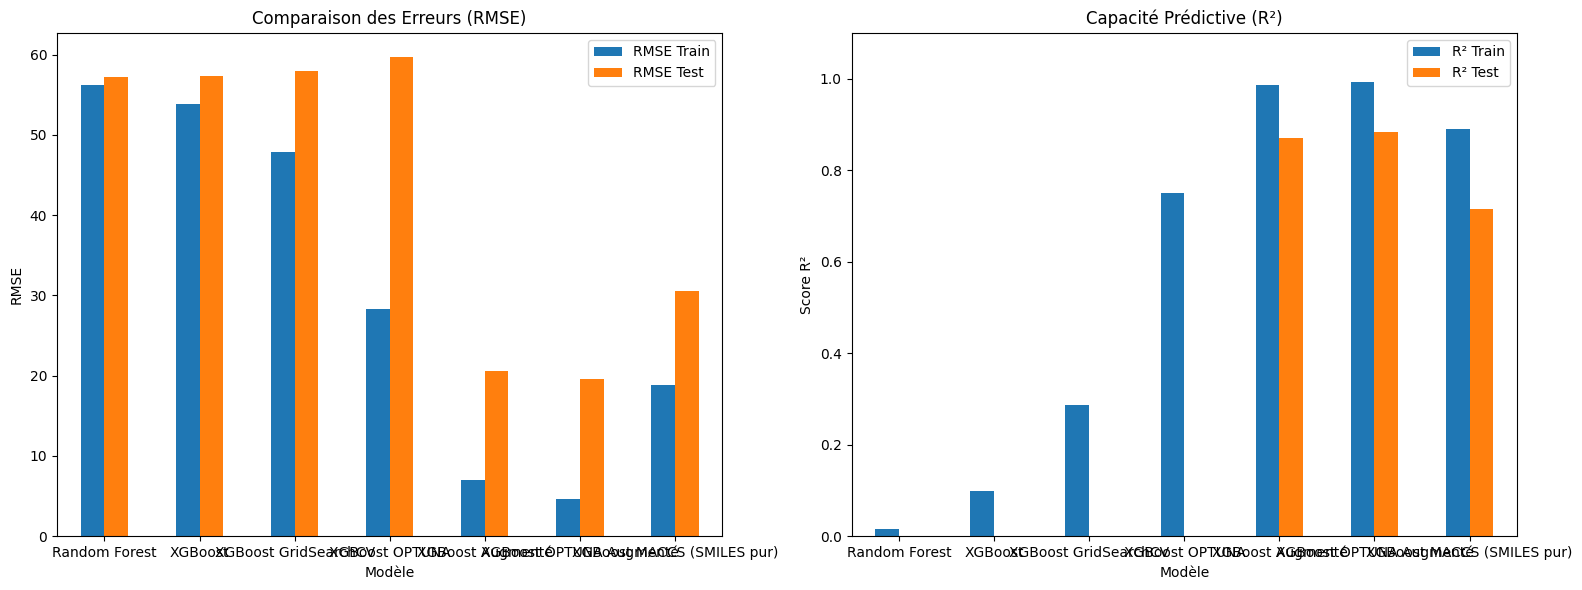

In [36]:
## RÉSULTATS FINAUX ##

import pandas as pd
import matplotlib.pyplot as plt

# 1. Génération du DataFrame final à partir des résultats accumulés
df_final_results = pd.DataFrame(all_results)

# 2. Affichage du tableau propre
print("📊 RÉCAPITULATIF COMPLET DES PERFORMANCES :")
# On trie par RMSE Test pour voir le meilleur modèle en haut
display(df_final_results.sort_values(by='RMSE Test'))

# 3. Graphique comparatif Multi-Indicateurs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique des RMSE (Plus bas est mieux)
df_final_results.set_index('Modèle')[['RMSE Train', 'RMSE Test']].plot(kind='bar', ax=ax1)
ax1.set_ylabel("RMSE")
ax1.set_title("Comparaison des Erreurs (RMSE)")
ax1.tick_params(axis='x', rotation=0)

# Graphique des R² (Plus haut est mieux, max 1.0)
df_final_results.set_index('Modèle')[['R² Train', 'R² Test']].plot(kind='bar', ax=ax2)
ax2.set_ylabel("Score R²")
ax2.set_ylim(0, 1.1) # Pour mieux voir la proximité de 1.0
ax2.set_title("Capacité Prédictive (R²)")
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# FONCTION DE PRÉDICTION INSTANTANÉE
def predict_maa_from_smiles(le_smiles, modele):
    mol = Chem.MolFromSmiles(le_smiles)
    if not mol:
        return "❌ SMILES invalide"
    
    # On génère le MACCS pour le SMILES donné et on le met au bon format (1 ligne, 167 colonnes)
    fp = np.array(MACCSkeys.GenMACCSKeys(mol)).reshape(1, -1)
    
    # On prédit directement
    pred = modele.predict(fp)[0]
    print(f"🧪 Molécule : {le_smiles:<20} | 🎯 MAA Max Prédite : {pred:.2f}")
    return pred

# --- TESTS EN DIRECT ---
print("-" * 60)
print("🔍 TESTS DE PRÉDICTION LIBRE")
print("-" * 60)

# Remplace ces chaînes par n'importe quel SMILES de ton choix
predict_maa_from_smiles("c1ccccc1", xgb_maccs)          # Benzène
predict_maa_from_smiles("CC(=O)C", xgb_maccs)           # Acétone
predict_maa_from_smiles("NOCc1cccc(I)c1", xgb_maccs)    # La molécule de ton précédent dataset